# Upsampling alignment of E145 and E165 by sOT

In [1]:
import os
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import torch
import pandas as pd
import numpy as np
import scanpy as sc
from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot,
    _recoverfull_new_new_knn
)

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Load adata

In [2]:
random_state = 23
np.random.seed(random_state)
    
ds_pts = 100

adata_all = sc.read_h5ad('../data/04.mouse.midbrain.three.time.point.ST.exp.h5ad')

sliceA=adata_all[adata_all.obs['Time point']=='E14.5']
sliceB=adata_all[adata_all.obs['Time point']=='E16.5']

adata_all.uns['annotation_colors']=['#9A154C', '#F3754E', '#5B58A7']

pair = "E145E165"

full_D_A = distance.cdist(sliceA.obsm['spatial'], sliceA.obsm['spatial'])
full_D_B = distance.cdist(sliceB.obsm['spatial'], sliceB.obsm['spatial'])
full_TestA = full_D_A[full_D_A>0]
full_TestB = full_D_B[full_D_B>0]
print(np.min(full_TestA), np.max(full_TestA), np.min(full_TestB), np.max(full_TestB))

13.341664064126334 5019.83874242988 10.440306508911908 5064.96051317283


In [3]:
downsampled_sliceA,indices_dsa, _ = _downsample.robust_maxmin_downsample_slice(sliceA, ds_pts)
downsampled_sliceB,indices_dsb, _ = _downsample.robust_maxmin_downsample_slice(sliceB, ds_pts)

M = np.array( pd.read_csv(f"./feature_matrix_23.csv", header=None) )
test_label = np.concatenate((np.array(sliceA.obs["annotation"]),np.array(sliceB.obs["annotation"])),axis=0)

D_A_test = distance.cdist(downsampled_sliceA.obsm['spatial'], downsampled_sliceA.obsm['spatial'])
D_B_test = distance.cdist(downsampled_sliceB.obsm['spatial'], downsampled_sliceB.obsm['spatial'])
testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
slice_scale = np.min([np.max(testA), np.max(testB)])
print(np.min(testA), np.max(testA), np.min(testB), np.max(testB))

96.56603957913983 4411.7363928503255 93.50935782048552 4836.09480883078


# Load alignment between downsampled slices in step 1

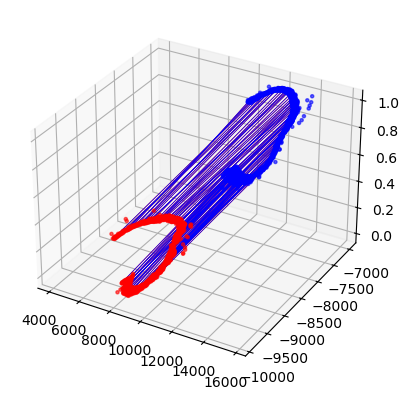

In [4]:
save_folder = "align_data"

gw_ratio = 6.5

cutoff_CC = 0.95

load_path = os.path.join(save_folder, f"ds_matching_{pair}_{gw_ratio}_{cutoff_CC}_relative.csv")

P = np.loadtxt(load_path, delimiter=",")

L_sig, L_full, indices_A_matched, indices_B_matched= _recoverfull_new_new_knn.generate_binary_matching_relative(sliceA, downsampled_sliceA, sliceB, downsampled_sliceB, P, save_folder)

_plot.plot_3d(sliceA.obsm['spatial'], sliceB.obsm['spatial'], L_sig, indices_A_matched, indices_B_matched, linewidth=0.5)

# Compute sOT with \rho_{f_2} = 10000 and \rho_t = 12

In [6]:
thresh_CGW_ratio_list = {12}
thresh_CCC_list = {10000}

for thresh_CCC in thresh_CCC_list:
    for thresh_CGW_ratio in thresh_CGW_ratio_list:
        print(f"------------------Running alignment for gw cutoff ratio {thresh_CGW_ratio}")
        P_full = _recoverfull_new_new_knn.recover_full_mapping_relative(M, sliceA.obsm['spatial'], sliceB.obsm['spatial'], L_sig, indices_A_matched, indices_B_matched, thresh_CGW_ratio=thresh_CGW_ratio, thresh_CCC=thresh_CCC, eps=0.01)
        P_full_dense = P_full.toarray()
        acc_benchmark = _metrics_two_gpr.cal_layer_based_alignment_result_threepoint_embryo_skip_all_zero(P_full_dense, test_label)
        print(f'P_sum and ARI for thresholds  {thresh_CGW_ratio}_{thresh_CCC}  is: {P_full_dense.sum()}_{acc_benchmark}')
        np.savetxt(f'./align_data/full_matching_{pair}_{gw_ratio}_{cutoff_CC}_{thresh_CGW_ratio}_{thresh_CCC}_{acc_benchmark}_relative.csv', P_full_dense, delimiter=",", fmt='%.8f')

------------------Running alignment for gw cutoff ratio 12


recover_full_mapping:  50%|█████     | 4/8 [00:01<00:01,  2.97it/s]

Number of blocked positions in recover_full sot: 1111372
Number of possble aligned positions in recover_full sot: 163742
After rescaling: min = 0.0664942257545298, max = 1.0.
After rescaling: min = 0.5698457078149092, max = 1.0.


Number of iterations in unot: 19921, final error: 9.98e-09
total row: 953, aligned row: 953
correct alignment: 825, rate: 0.8657
P_sum and ARI for thresholds  12_10000  is: 0.973732719369346_0.8656873032528857
